In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from dataclasses import dataclass
%load_ext autoreload
%autoreload 2

In [4]:
from occupancy import *


# Most basic negative sum
In general nse wants to detect a point where different subtractions all reach 0 at the same time.
The basic equation is $F_0 - N \Delta F$. Ideally $\frac{F_0}{\Delta F} = N$ for all $q$. 


In [58]:
@dataclass
class Conf:
    size: int
    maxN : int
    umin: float
    umax: float
    trueN: float
    fit_largest: int
    max_sigma:float=1

conf = Conf(
    size = 500,
    maxN = 20,
    umin= 1.5,
    umax = 8.5,
    trueN = 7,
    fit_largest = 3,
)


In [6]:
def get_negsum(f0, delta, conf):
    allN = np.arange(0,conf.maxN,.3, dtype=float)
    f1s = f0[None]-delta[None]*allN[:,None]
    negsum = np.array([-np.sum(f1[f1<0]) for f1 in f1s])
    return allN, negsum


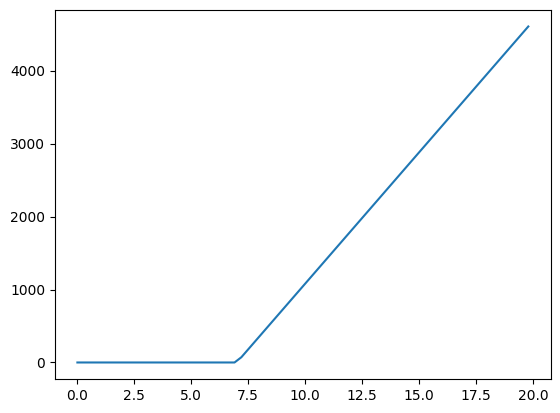

In [7]:

f0 = np.random.uniform(conf.umin,conf.umax,conf.size)
delta = f0/conf.trueN
allN, negsum = get_negsum(f0, delta, conf)
plt.plot(allN,negsum)

In [37]:
np.max(clean_delta)

1.2140520096505127

7.999981829207414
0.001 0.0
0.01 0.0
0.05 5.090150540299874
0.1 6.0782619279762
0.3 2.708446951548467


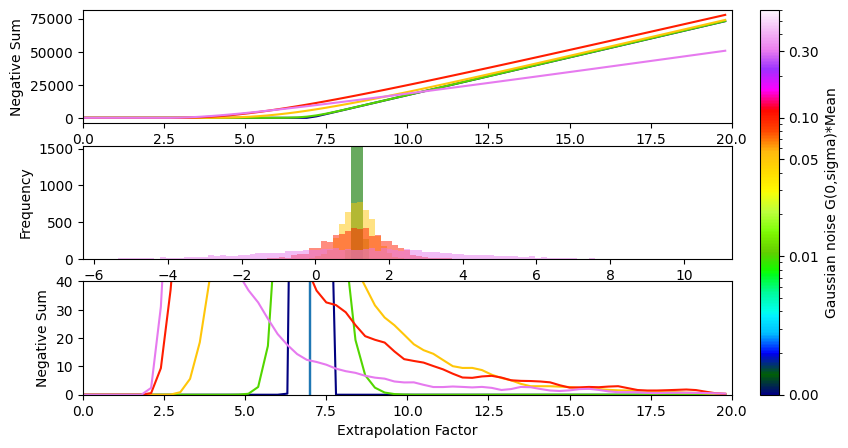

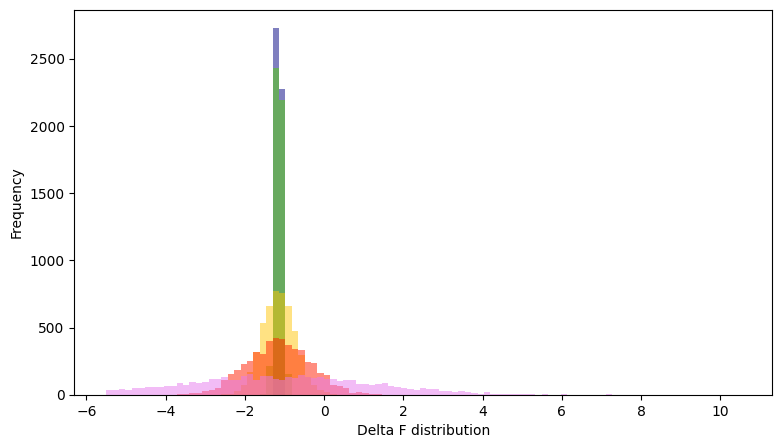

In [92]:
conf = Conf(
    size = 5000,
    maxN = 20,
    umin= 7.5,
    umax = 8.5,
    trueN = 7,
    fit_largest = 3,
)
f0 = np.random.uniform(conf.umin,conf.umax,conf.size)
sigmas = [1e-3,0.01, 0.05, 0.1, 0.3]
# sigmas = [1e-9 ,0.3]

cmap = cm.viridis
cmap = cm.gist_ncar
norm = mcolors.LogNorm(vmin=min(sigmas), vmax=max(sigmas)*2)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)

# Plot with colormap
fig, axs = plt.subplots(3, figsize=(9,5))
fig2, ax2 = plt.subplots(1, figsize=(9,5))
bins = np.linspace(-5.5,10.5,100)
ff = 0
print(np.mean(f0))
for ii, sigma in enumerate(sigmas): 
    color = cmap(norm(sigma))
    noise = np.mean(f0)*np.random.normal(0,sigma, size=conf.size)
    clean_delta = f0/conf.trueN
    delta = clean_delta + noise
    mask = delta<3
    allN, negsum = get_negsum(f0[mask], delta[mask], conf)

    ax = axs[0]
    ax.plot(allN,negsum, color=color, )
    ax.set_ylabel("Negative Sum")
    ax.set_xlabel("Extrapolation Factor")
    ax = axs[1]
    # if (ii+1)%2:
    freq,_,_ =  ax.hist(delta, color=color, alpha=0.5, bins=bins)
    ff = max(np.max(freq),ff)
    ax.set_ylabel("Frequency")
    ax.set_xlabel("Delta F distribution")
    ax = ax2
    # if (ii+1)%2:
    freq,_,_ =  ax.hist(-delta, color=color, alpha=0.5, bins=bins)
    ff = max(np.max(freq),ff)
    ax.set_ylabel("Frequency")
    ax.set_xlabel("Delta F distribution")
    ax = axs[2]
    ax.axvline(conf.trueN)
    secdev = np.gradient(np.gradient(negsum))
    print(sigma,np.median(secdev))
    ax.plot(allN,np.gradient(np.gradient(negsum)), color=color, )
    ax.set_ylabel("Negative Sum")
    ax.set_xlabel("Extrapolation Factor")
axs[1].set_ylim(0,np.max(ff)/2)
axs[2].set_ylim(0,40)
axs[2].set_xlim(0,20)
axs[0].set_xlim(0,20)
# axs[0].set_ylim(0,400)
cbar = fig.colorbar(sm, ax=axs, orientation="vertical", fraction=0.03, pad=0.04)
cbar.set_label("Gaussian noise G(0,sigma)*Mean")
cbar.set_ticks(sigmas)
cbar.set_ticklabels([f"{s:.2f}" for s in sigmas])
# axs[0].set_xlim(40,50)
# axs[0].set_ylim(50_000,70_000)
# cbar = plt.colorbar(sm)

intersection point, 0.286 (7.00)
0.001 7.0
intersection point, 0.286 (7.00)
0.01 6.996
intersection point, 0.295 (6.79)
0.05 6.785
intersection point, 0.348 (5.75)
0.1 5.746
intersection point, 0.625 (3.20)
0.3 3.2


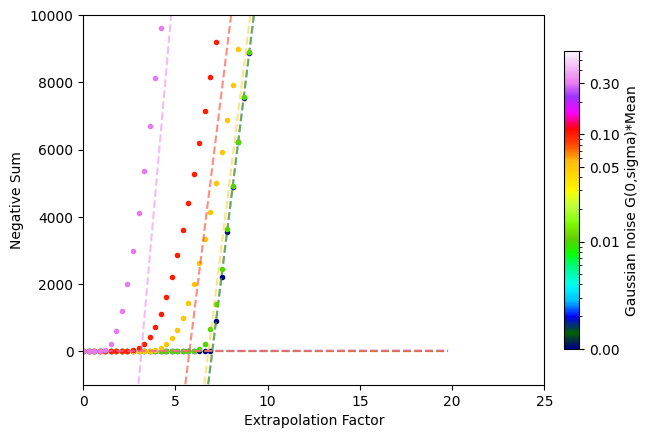

In [93]:
# sigmas = [1e-3, 0.05, 0.1, 0.3]
fig, ax = plt.subplots(1,1)
bins = np.linspace(-2,2,100)
for ii, sigma in enumerate(sigmas): 
    color = cmap(norm(sigma))
    noise = np.mean(f0)*np.random.normal(0,sigma, size=conf.size)
    delta = f0/conf.trueN + noise
    # mask = delta<2.5
    allN, negsum = get_negsum(f0[mask], delta[mask], conf)

    alpha_line, fit_lowest, fit_biggest = get_fits(-negsum, allN, conf.fit_largest)
    ax.plot(allN,negsum, ".", color=color, )
    ax.plot(alpha_line,fit_lowest, "--", color=color, alpha=0.5)
    ax.plot(alpha_line,fit_biggest, "--",  color=color, alpha=0.5)
    ax.set_xlim(0,25)
    ax.set_ylim(-1000,10_000)
    from compare_conds import get_intersect_and_angle
    print(sigma, np.round(get_intersect_and_angle(allN, negsum, 5)[0],3))

    
ax.set_ylabel("Negative Sum")
ax.set_xlabel("Extrapolation Factor")
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.03, pad=0.04)
cbar.set_label("Gaussian noise G(0,sigma)*Mean")
cbar.set_ticks(sigmas)
cbar.set_ticklabels([f"{s:.2f}" for s in sigmas])


In [97]:
from compare_conds import get_intersect_and_angle
sigmas = np.linspace(0,0.5,50)
bins = np.linspace(-2,2,100)
intersects = []
intersect_stdev = []
for ii, sigma in enumerate(sigmas): 
    isects = []
    for _ in range(10):
        # color = cmap(norm(sigma))
        noise = np.mean(f0)*np.random.normal(0,sigma, size=conf.size)
        delta = f0/conf.trueN + noise
        # mask = delta<2.5
        allN, negsum = get_negsum(f0[mask], delta[mask], conf)

        alpha_line, fit_lowest, fit_biggest = get_fits(-negsum, allN, conf.fit_largest)
        # ax.plot(allN,negsum, ".", color=color, )
        # ax.plot(alpha_line,fit_lowest, "--", color=color, alpha=0.5)
        # ax.plot(alpha_line,fit_biggest, "--",  color=color, alpha=0.5)
        # ax.set_xlim(0,25)
        # ax.set_ylim(-1000,10_000)

        isect = get_intersect_and_angle(allN, negsum, 5)[0]
        isects.append( isect)
    intersects.append( np.mean(isects))
    intersect_stdev.append( np.std(isects))

Text(0.5, 0, 'Sigma')

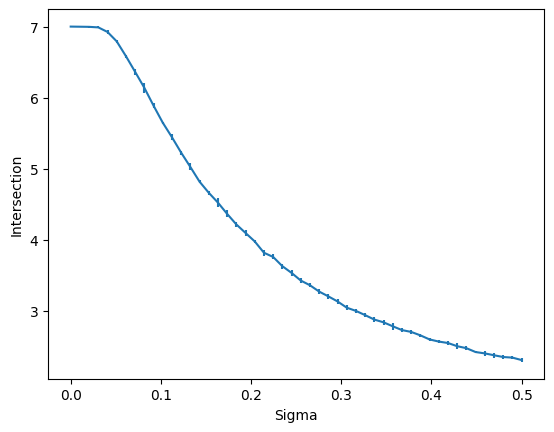

In [101]:
fig, ax = plt.subplots(1,1)
ax.errorbar(sigmas,intersects, intersect_stdev,)
    
ax.set_ylabel("Intersection")
ax.set_xlabel("Sigma")


In [ ]:
from compare_conds import get_intersect_and_angle
sigmas = np.linspace(0,0.3,10)
fig, ax = plt.subplots(1,1)
bins = np.linspace(-2,2,100)
intersects = []
for ii, sigma in enumerate(sigmas): 
    # color = cmap(norm(sigma))
    noise = np.mean(f0)*np.random.normal(0,sigma, size=conf.size)
    delta = f0/conf.trueN + noise
    # mask = delta<2.5
    allN, negsum = get_negsum(f0[mask], delta[mask], conf)

    alpha_line, fit_lowest, fit_biggest = get_fits(-negsum, allN, conf.fit_largest)
    # ax.plot(allN,negsum, ".", color=color, )
    # ax.plot(alpha_line,fit_lowest, "--", color=color, alpha=0.5)
    # ax.plot(alpha_line,fit_biggest, "--",  color=color, alpha=0.5)
    # ax.set_xlim(0,25)
    # ax.set_ylim(-1000,10_000)
    
    isect = get_intersect_and_angle(allN, negsum, 5)[0]
    intersects.append( isect)

ax.plot(sigmas,intersects, "x")
    
ax.set_ylabel("Negative Sum")
ax.set_xlabel("Sigma")
# cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.03, pad=0.04)
cbar.set_label("Gaussian noise G(0,sigma)*Mean")
cbar.set_ticks(sigmas)
cbar.set_ticklabels([f"{s:.2f}" for s in sigmas])


intersection point, 0.270 (7.42)
7.419538701760516
0.2 0.1919616559495978


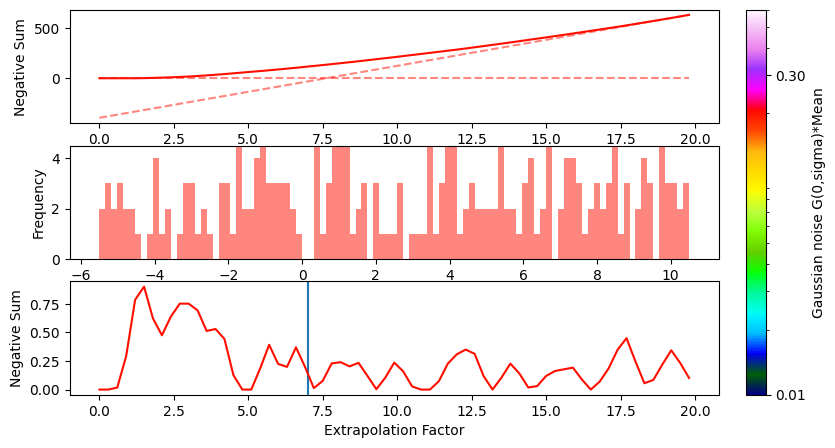

In [84]:
conf = Conf(
    size = 500,
    maxN = 20,
    umin= 1.5,
    umax = 25.5,
    trueN = 7,
    fit_largest = 3,
    max_sigma = 0.5
)
max_sigma = 1.8
f0 = np.random.uniform(conf.umin,conf.umax,conf.size)
fsigma = np.random.uniform(0.3,max_sigma,conf.size)
sigmas = [0.01,0.3]
cmap = cm.gist_ncar
norm = mcolors.LogNorm(vmin=min(sigmas), vmax=max(sigmas)*2)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sigma=0.2

# Plot with colormap
fig, axs = plt.subplots(3, figsize=(9,5))
bins = np.linspace(-5.5,10.5,100)
ff = 0
color = cmap(norm(sigma))
noise = np.mean(f0)*np.random.normal(0,fsigma)
clean_delta = f0/conf.trueN
delta = clean_delta + noise
mask = delta<3
allN, negsum = get_negsum(f0[mask], delta[mask], conf)

ax = axs[0]
ax.plot(allN,negsum, color=color, )
ax.set_ylabel("Negative Sum")
ax.set_xlabel("Extrapolation Factor")
alpha_line, fit_lowest, fit_biggest = get_fits(-negsum, allN, conf.fit_largest)
ax.plot(alpha_line,fit_lowest, "--", color=color, alpha=0.5)
ax.plot(alpha_line,fit_biggest, "--",  color=color, alpha=0.5)
    
isect = get_intersect_and_angle(allN, negsum, 5)[0]
print(isect)
    
    
ax = axs[1]
# if (ii+1)%2:
freq,_,_ =  ax.hist(delta, color=color, alpha=0.5, bins=bins)
ff = max(np.max(freq),ff)
ax.set_ylabel("Frequency")
ax.set_xlabel("Delta F distribution")
ax = ax2
# if (ii+1)%2:
freq,_,_ =  ax.hist(-delta, color=color, alpha=0.5, bins=bins)
ff = max(np.max(freq),ff)
ax.set_ylabel("Frequency")
ax.set_xlabel("Delta F distribution")
ax = axs[2]
ax.axvline(conf.trueN)
secdev = np.gradient(np.gradient(negsum))
print(sigma,np.median(secdev))
ax.plot(allN,np.gradient(np.gradient(negsum)), color=color, )
ax.set_ylabel("Negative Sum")
ax.set_xlabel("Extrapolation Factor")
axs[1].set_ylim(0,np.max(ff)/2)
# axs[0].set_ylim(0,400)
cbar = fig.colorbar(sm, ax=axs, orientation="vertical", fraction=0.03, pad=0.04)
cbar.set_label("Gaussian noise G(0,sigma)*Mean")
cbar.set_ticks(sigmas)
cbar.set_ticklabels([f"{s:.2f}" for s in sigmas])
# axs[0].set_xlim(40,50)
# axs[0].set_ylim(50_000,70_000)
# cbar = plt.colorbar(sm)
